In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [2]:
df1 = pd.read_csv('SM_1_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('SM_2_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('SM_3_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('SM_5_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('SM_6_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")

dfs = [df1, df2, df3, df5, df6]
combined_df = pd.concat(dfs, ignore_index=True)

combined_df = combined_df.dropna(subset=["SWC_5","SWC_10","SWC_20","SWC_50","T_5","T_10","T_20","T_50"])

In [3]:
print(combined_df)

        Ppt  SWC_5  SWC_10  SWC_20  SWC_50    T_5   T_10   T_20   T_50  Flag
0       0.0  0.139   0.178   0.148   0.152   2.81   4.40   5.77  10.57     3
1       0.0  0.139   0.178   0.148   0.152   2.86   4.38   5.71  10.51     3
2       0.0  0.139   0.178   0.148   0.152   2.89   4.35   5.66  10.47     3
3       0.0  0.139   0.178   0.148   0.152   2.90   4.33   5.62  10.41     3
4       0.0  0.139   0.178   0.148   0.152   2.96   4.32   5.59  10.36     3
...     ...    ...     ...     ...     ...    ...    ...    ...    ...   ...
295800  0.0  0.162   0.160   0.162   0.101  28.76  29.05  28.94  27.89     3
295801  0.0  0.162   0.160   0.161   0.101  28.24  28.61  28.75  27.98     3
295802  0.0  0.162   0.159   0.161   0.101  27.80  28.21  28.53  28.05     3
295803  0.0  0.162   0.159   0.160   0.101  27.44  27.87  28.30  28.10     3
295804  0.0  0.161   0.159   0.160   0.101  27.15  27.60  28.08  28.15     3

[283037 rows x 10 columns]


In [4]:
nan_mask = combined_df.isna()
nan_counts = nan_mask.sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [5]:
X = combined_df[['T_5', 'T_10', 'T_20']]
y = combined_df['T_50']

model = LinearRegression()

model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 1.20667687 -2.89202375  2.56028453]
Intercept: 2.716213163028076


In [7]:
df4 = pd.read_csv('SM_4_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")

for i, row in df4.iterrows():
    df4.at[i, "T_50"] = row['T_5']*model.coef_[0] + row['T_10']*model.coef_[1] + row['T_20']*model.coef_[2] + model.intercept_  

                     Ppt  SWC_5  SWC_10  SWC_20  SWC_50    T_5   T_10   T_20  \
Date                                                                           
2015-01-01 00:00:00  0.0  0.232   0.253   0.199     NaN   2.60   4.05   8.15   
2015-01-01 01:00:00  0.0  0.232   0.253   0.199     NaN   2.60   4.01   8.08   
2015-01-01 02:00:00  0.0  0.231   0.253   0.199     NaN   2.59   3.97   8.03   
2015-01-01 03:00:00  0.0  0.232   0.254   0.199     NaN   2.61   3.94   7.95   
2015-01-01 04:00:00  0.0  0.232   0.254   0.199     NaN   2.64   3.93   7.90   
...                  ...    ...     ...     ...     ...    ...    ...    ...   
2021-09-30 20:00:00  0.0  0.280   0.293   0.232     NaN  25.79  26.55  26.04   
2021-09-30 21:00:00  0.0  0.279   0.292   0.232     NaN  25.29  26.14  26.11   
2021-09-30 22:00:00  0.0  0.278   0.292   0.231     NaN  24.91  25.80  26.14   
2021-09-30 23:00:00  0.0  0.277   0.291   0.231     NaN  24.53  25.49  26.12   
2021-10-01 00:00:00  0.0  0.276   0.290 

In [8]:
# df4 = pd.read_csv('SM_4_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
# for val in list(df4.columns.values):
#     if df4[val].isnull().values.any():
#         print(val)
        
# print()
# nan_mask = df4.isna()
# nan_counts = nan_mask.sum()
# print(nan_counts[nan_counts > 0])

In [9]:
A = combined_df[['SWC_5', 'SWC_10', 'SWC_20']]
B = combined_df['SWC_50']

new_model = LinearRegression()

new_model.fit(A, B)

print("Coefficients:", new_model.coef_)
print("Intercept:", new_model.intercept_)

for i, row in df4.iterrows():
    df4.at[i, "SWC_50"] = row['SWC_5']*new_model.coef_[0] + row['SWC_10']*new_model.coef_[1] + row['SWC_20']*new_model.coef_[2] + new_model.intercept_  

print(df4)

Coefficients: [ 0.74823341 -2.11916282  2.46351708]
Intercept: -0.003379138369209833
                     Ppt  SWC_5  SWC_10  SWC_20    SWC_50    T_5   T_10  \
Date                                                                      
2015-01-01 00:00:00  0.0  0.232   0.253   0.199  0.124303   2.60   4.05   
2015-01-01 01:00:00  0.0  0.232   0.253   0.199  0.124303   2.60   4.01   
2015-01-01 02:00:00  0.0  0.231   0.253   0.199  0.123554   2.59   3.97   
2015-01-01 03:00:00  0.0  0.232   0.254   0.199  0.122184   2.61   3.94   
2015-01-01 04:00:00  0.0  0.232   0.254   0.199  0.122184   2.64   3.93   
...                  ...    ...     ...     ...       ...    ...    ...   
2021-09-30 20:00:00  0.0  0.280   0.293   0.232  0.156747  25.79  26.55   
2021-09-30 21:00:00  0.0  0.279   0.292   0.232  0.158118  25.29  26.14   
2021-09-30 22:00:00  0.0  0.278   0.292   0.231  0.154907  24.91  25.80   
2021-09-30 23:00:00  0.0  0.277   0.291   0.231  0.156278  24.53  25.49   
2021-10-01 00:0

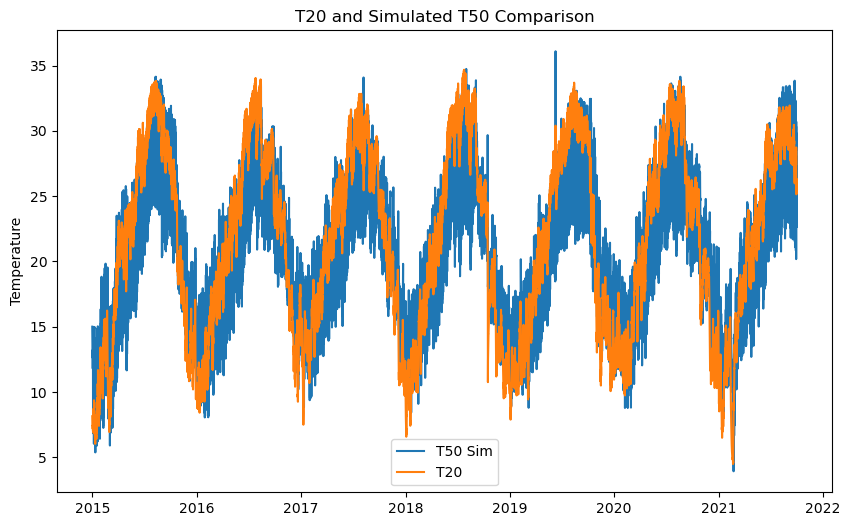

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(df4['T_50'], label='T50 Sim')
plt.plot(df4['T_20'], label='T20')

plt.ylabel('Temperature')
plt.title('T20 and Simulated T50 Comparison')

plt.legend()
plt.show()

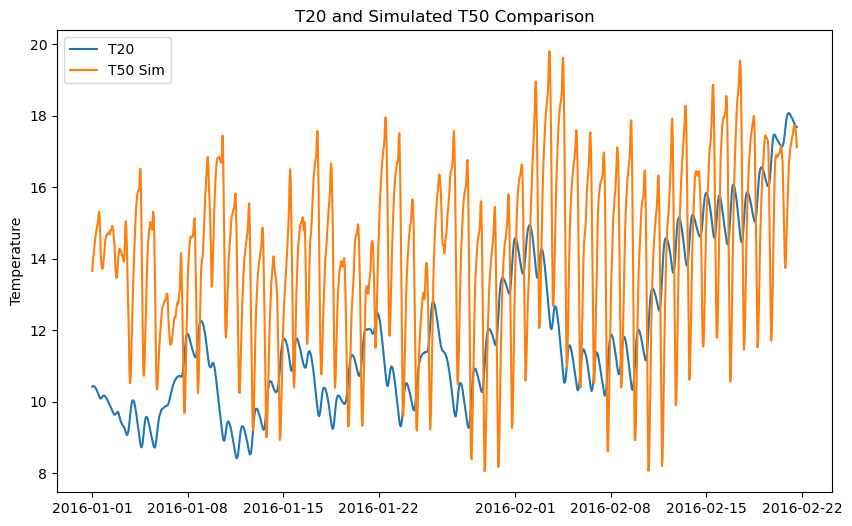

In [21]:
df4_sliced = df4[8760:10000]
plt.figure(figsize=(10, 6))
plt.plot(df4_sliced['T_20'], label='T20')
plt.plot(df4_sliced['T_50'], label='T50 Sim')

plt.ylabel('Temperature')
plt.title('T20 and Simulated T50 Comparison')

plt.legend()
plt.show()